# 🧪 Medical Image Preprocessing — Complete Pipeline
## X-Ray · CT Scan · MRI Brain Tumor

### What this notebook does:
1. **Reads** raw images from `DATASETS/` (XRAY / CT / MRI subfolders)
2. **Validates** every image: size, corruption, NaN/Inf checks
3. **Preprocesses** per modality: CLAHE (X-Ray), Gaussian denoise (CT), Percentile norm (MRI)
4. **Saves TWO outputs per split:**
   - `X.npy` — float32 tensors (224×224×3) for model training
   - `X_visual.npy` — uint8 images (224×224×3) for human inspection
5. **Verifies** all saved files before finishing

### Expected folder layout:
```
DATASETS/
  XRAY/          ← or xray / X-Ray / x-ray
    COVID/
    Lung_Opacity/
    Normal/
    Viral Pneumonia/
  CT/            ← or ct / CT_Scan
    train/
      adenocarcinoma/  large.cell.carcinoma/  normal/  squamous.cell.carcinoma/
    test/
      (same folders)
  MRI/           ← or mri / Brain_Tumor
    Training/
      glioma/  meningioma/  notumor/  pituitary/
    Testing/
      (same folders)
```

### Outputs saved to `preprocessed/`:
```
preprocessed/
  xray/train/  val/  test/  → X.npy, y.npy, X_visual.npy, classes.npy
  ct/  train/  val/  test/  → same
  mri/ train/  val/  test/  → same
```

In [1]:
# ── CELL 1 — Imports & Config ────────────────────────────────────────────────
import os, gc, warnings
import numpy as np
import cv2
from pathlib import Path
from collections import Counter
from PIL import Image as PILImage
warnings.filterwarnings('ignore')

SEED       = 42
IMG_SIZE   = 224    # ALL images must be this size — validated strictly
VAL_RATIO  = 0.15
TEST_RATIO = 0.15

np.random.seed(SEED)

DATA_DIR = Path('DATASETS')
OUT_DIR  = Path('preprocessed')
OUT_DIR.mkdir(exist_ok=True)

VALID_EXTS = {'.png', '.jpg', '.jpeg', '.bmp', '.tif', '.tiff'}

print(f'Data root : {DATA_DIR.resolve()}')
print(f'Output    : {OUT_DIR.resolve()}')
print(f'IMG_SIZE  : {IMG_SIZE}  ← ALL tensors will be this size')
print()
if not DATA_DIR.exists():
    print(f'⚠️  WARNING: {DATA_DIR.resolve()} does not exist!')
    print('    Create it or change DATA_DIR above.')
else:
    print('✅ Data root found. Contents:')
    for p in sorted(DATA_DIR.iterdir()):
        print(f'   {p.name}/')


Data root : C:\Users\Naveen kumar\OneDrive\Documents\Attachments\Desktop\multi model roi project\DATASETS
Output    : C:\Users\Naveen kumar\OneDrive\Documents\Attachments\Desktop\multi model roi project\preprocessed
IMG_SIZE  : 224  ← ALL tensors will be this size

⚠️  WARNING: C:\Users\Naveen kumar\OneDrive\Documents\Attachments\Desktop\multi model roi project\DATASETS does not exist!
    Create it or change DATA_DIR above.


In [2]:
# ── CELL 2 — Image I/O, Validation, and Preprocessing Functions ─────────────

def list_image_paths(folder: Path):
    """Return sorted list of image paths in a folder (non-recursive)."""
    return sorted([p for p in folder.iterdir()
                   if p.suffix.lower() in VALID_EXTS])


def read_and_validate_image(path: Path):
    try:
        pil = PILImage.open(path).convert('RGB')
        pil = pil.resize((IMG_SIZE, IMG_SIZE), PILImage.LANCZOS)
        img = np.array(pil, dtype=np.uint8)  # HWC uint8

        # Validate shape strictly
        if img.shape != (IMG_SIZE, IMG_SIZE, 3):
            return None, f'Shape mismatch: {img.shape} expected ({IMG_SIZE},{IMG_SIZE},3)'

        # Reject blank / near-black images (corrupted scans)
        if img.std() < 3.0:
            return None, f'Near-blank image (std={img.std():.2f}) — likely corrupted'

        # Reject images with any NaN/Inf after conversion
        if np.isnan(img.astype(np.float32)).any():
            return None, 'NaN values in image'

        return img, None

    except Exception as e:
        return None, str(e)


# ── Per-modality preprocessing ───────────────────────────────────────────────

def preprocess_xray(img_uint8: np.ndarray) -> np.ndarray:
    """
    X-Ray: Grayscale → CLAHE (local contrast enhancement) → 3-channel float32 [0,1].
    CLAHE enhances lung and rib structures that are critical for COVID/opacity detection.
    """
    gray  = cv2.cvtColor(img_uint8, cv2.COLOR_RGB2GRAY)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    gray  = clahe.apply(gray)
    f     = gray.astype(np.float32) / 255.0
    return np.stack([f, f, f], axis=-1)   # HWC float32 [0,1]


def preprocess_ct(img_uint8: np.ndarray) -> np.ndarray:
    """
    CT Scan: RGB → mild Gaussian denoising → float32 [0,1].
    Gaussian blur reduces noise while preserving tumour boundary contrast.
    """
    img = cv2.GaussianBlur(img_uint8, (3, 3), 0)
    return img.astype(np.float32) / 255.0   # HWC float32 [0,1]


def preprocess_mri(img_uint8: np.ndarray) -> np.ndarray:
    """
    MRI Brain Tumor: Grayscale → percentile normalisation [2,98] → 3-channel float32 [0,1].
    Percentile norm removes extreme bright/dark artefacts common in MRI sequences.
    """
    gray    = cv2.cvtColor(img_uint8, cv2.COLOR_RGB2GRAY).astype(np.float32)
    p2, p98 = np.percentile(gray, [2, 98])
    gray    = np.clip(gray, p2, p98)
    gray    = (gray - p2) / (p98 - p2 + 1e-8)
    gray    = gray.astype(np.float32)
    return np.stack([gray, gray, gray], axis=-1)   # HWC float32 [0,1]


def float32_to_visual_uint8(img_float32: np.ndarray) -> np.ndarray:
    """Convert float32 HWC [0,1] → uint8 HWC [0,255] for visual saving."""
    return np.clip(img_float32 * 255, 0, 255).astype(np.uint8)


PREPROCESSORS = {
    'xray': preprocess_xray,
    'ct':   preprocess_ct,
    'mri':  preprocess_mri,
}

print('✅ Preprocessing functions ready.')
print()
print('Modality  |  Technique             |  Why')
print('---------|------------------------|----------------------------------------------')
print('X-Ray    |  CLAHE                 |  Enhance rib/lung contrast for COVID detection')
print('CT Scan  |  Gaussian blur (3×3)   |  Denoise while keeping tumour boundaries')
print('MRI      |  Percentile norm [2,98]|  Remove MRI signal artefacts / hotspots')


✅ Preprocessing functions ready.

Modality  |  Technique             |  Why
---------|------------------------|----------------------------------------------
X-Ray    |  CLAHE                 |  Enhance rib/lung contrast for COVID detection
CT Scan  |  Gaussian blur (3×3)   |  Denoise while keeping tumour boundaries
MRI      |  Percentile norm [2,98]|  Remove MRI signal artefacts / hotspots


In [3]:
# ── CELL 3 — Memory-Safe Write to Disk (np.memmap) ──────────────────────────
#
# TWO files are saved per split:
#   X.npy       → float32 tensors (input to model)
#   X_visual.npy→ uint8  images  (human inspection / debugging)
#   y.npy       → int64  labels
#
# Uses np.memmap → only chunk_size images in RAM at a time.
# Even 21,000 X-ray images use only ~10 MB RAM per chunk.

def write_split_both(paths_labels, preprocess_fn, out_dir: Path, split: str,
                     chunk_size: int = 64):
    """
    Write X.npy (float32 tensors) and X_visual.npy (uint8 RGB) to disk.
    Processes chunk_size images at a time — constant ~10 MB RAM usage.
    Also reports how many images were skipped due to validation errors.
    """
    out_dir.mkdir(parents=True, exist_ok=True)
    n = len(paths_labels)
    if n == 0:
        print(f'    ⚠️  {split}: 0 samples — skipping')
        return 0

    x_path      = str(out_dir / 'X.npy')
    x_vis_path  = str(out_dir / 'X_visual.npy')
    y_path      = str(out_dir / 'y.npy')

    # Pre-allocate both memmaps on disk (no RAM used yet)
    X_tensor  = np.memmap(x_path,     dtype='float32', mode='w+',
                          shape=(n, IMG_SIZE, IMG_SIZE, 3))
    X_visual  = np.memmap(x_vis_path, dtype='uint8',   mode='w+',
                          shape=(n, IMG_SIZE, IMG_SIZE, 3))
    y_arr     = np.zeros(n, dtype=np.int64)

    written = 0
    skipped = 0

    for start in range(0, n, chunk_size):
        chunk = paths_labels[start:start + chunk_size]
        for local_i, (path, label) in enumerate(chunk):
            img_uint8, err = read_and_validate_image(path)

            if img_uint8 is None:
                # Blank placeholder — model will see a near-zero image
                X_tensor[written + local_i] = np.zeros(
                    (IMG_SIZE, IMG_SIZE, 3), dtype=np.float32)
                X_visual[written + local_i] = np.zeros(
                    (IMG_SIZE, IMG_SIZE, 3), dtype=np.uint8)
                skipped += 1
                # Only print first 5 errors to avoid flood
                if skipped <= 5:
                    print(f'      ⚠️  Skip [{path.name}]: {err}')
            else:
                processed              = preprocess_fn(img_uint8)  # float32 [0,1]
                X_tensor[written + local_i]  = processed
                X_visual[written + local_i]  = float32_to_visual_uint8(processed)

            y_arr[written + local_i] = label

        X_tensor.flush()
        X_visual.flush()
        written += len(chunk)

    del X_tensor, X_visual  # close memmaps — data stays on disk
    np.save(y_path, y_arr)

    dist = dict(sorted(Counter(y_arr.tolist()).items()))
    skip_msg = f'  ({skipped} skipped)' if skipped > 0 else ''
    print(f'    ✅ {split:5s}: {n:6d} samples  dist={dist}{skip_msg}')
    gc.collect()
    return n

def stratified_split_indices(labels, val_ratio, test_ratio, seed=42):
    """
    Stratified split on indices only — no image data in RAM.
    Returns (train_idx, val_idx, test_idx).
    """
    rng = np.random.default_rng(seed)
    tr_i, va_i, te_i = [], [], []
    for cls in np.unique(labels):
        idx   = np.where(labels == cls)[0]
        rng.shuffle(idx)
        n_cls  = len(idx)
        n_test = max(1, int(n_cls * test_ratio))
        n_val  = max(1, int(n_cls * val_ratio))
        n_val  = min(n_val, n_cls - n_test - 1)
        n_test = min(n_test, n_cls - 1)
        n_val  = max(1, n_val)
        te_i.extend(idx[:n_test].tolist())
        va_i.extend(idx[n_test:n_test + n_val].tolist())
        tr_i.extend(idx[n_test + n_val:].tolist())
    return (np.array(tr_i, dtype=np.int64),
            np.array(va_i, dtype=np.int64),
            np.array(te_i, dtype=np.int64))

print('✅ Memory-safe write functions ready.')
print(f'   RAM per chunk (64 images): '
      f'  float32={64*224*224*3*4/1024**2:.1f} MB'
      f'  uint8={64*224*224*3/1024**2:.1f} MB')


✅ Memory-safe write functions ready.
   RAM per chunk (64 images):   float32=36.8 MB  uint8=9.2 MB


In [4]:
# ── CELL 4 — X-Ray Preprocessing ────────────────────────────────────────────
print('\n' + '='*65)
print('X-RAY PREPROCESSING')
print('Classes: COVID | Lung_Opacity | Normal | Viral Pneumonia')
print('='*65)

XRAY_CLASSES = ['COVID', 'Lung_Opacity', 'Normal', 'Viral Pneumonia']

# Locate XRAY folder (case-insensitive search)
xray_base = None
for candidate in ['XRAY', 'xray', 'Xray', 'X-Ray', 'x-ray', 'XRay']:
    p = DATA_DIR / candidate
    if p.exists():
        xray_base = p; break

if xray_base is None:
    raise FileNotFoundError(
        f'XRAY folder not found inside {DATA_DIR.resolve()}\n'
        f'Tried: XRAY, xray, Xray, X-Ray, x-ray'
    )
print(f'Found XRAY at: {xray_base.resolve()}')

xray_out = OUT_DIR / 'xray'
xray_out.mkdir(exist_ok=True)
xray_has_splits = all((xray_base / s).exists() for s in ['train', 'val', 'test'])

if xray_has_splits:
    print('Mode: Pre-split train/val/test folders found.')
    for split in ['train', 'val', 'test']:
        paths_labels = []
        for lid, cls in enumerate(XRAY_CLASSES):
            cls_dir = xray_base / split / cls
            if not cls_dir.exists():
                print(f'  ⚠️  Missing: {cls_dir}'); continue
            paths = list_image_paths(cls_dir)
            print(f'  [{split}] {cls}: {len(paths)} images')
            paths_labels.extend([(p, lid) for p in paths])
        rng = np.random.default_rng(SEED)
        rng.shuffle(paths_labels)
        write_split_both(paths_labels, preprocess_xray, xray_out / split, split)
else:
    print('Mode: Class folders → stratified train/val/test split.')
    all_paths_labels = []
    for lid, cls in enumerate(XRAY_CLASSES):
        # Support XRAY/COVID/  or  XRAY/COVID/images/
        cls_dir = xray_base / cls / 'images'
        if not cls_dir.exists():
            cls_dir = xray_base / cls
        if not cls_dir.exists():
            print(f'  ⚠️  Not found: {cls}'); continue
        paths = list_image_paths(cls_dir)
        print(f'  {cls}: {len(paths)} images')
        all_paths_labels.extend([(p, lid) for p in paths])

    if len(all_paths_labels) == 0:
        raise FileNotFoundError('No X-Ray images found. Check DATASETS/XRAY folder.')

    all_labels = np.array([lb for _, lb in all_paths_labels], dtype=np.int64)
    tr_idx, va_idx, te_idx = stratified_split_indices(
        all_labels, VAL_RATIO, TEST_RATIO, SEED)
    print(f'  Split: train={len(tr_idx)}, val={len(va_idx)}, test={len(te_idx)}')
    for split, indices in [('train', tr_idx), ('val', va_idx), ('test', te_idx)]:
        subset = [all_paths_labels[i] for i in indices]
        write_split_both(subset, preprocess_xray, xray_out / split, split)

np.save(str(xray_out / 'classes.npy'), np.array(XRAY_CLASSES))
print(f'\n✅ X-Ray complete.')
print(f'   Saved: X.npy (float32 tensors) + X_visual.npy (uint8 images) per split')
gc.collect()



X-RAY PREPROCESSING
Classes: COVID | Lung_Opacity | Normal | Viral Pneumonia


FileNotFoundError: XRAY folder not found inside C:\Users\Naveen kumar\OneDrive\Documents\Attachments\Desktop\multi model roi project\DATASETS
Tried: XRAY, xray, Xray, X-Ray, x-ray

In [ ]:
# ── CELL 5 — CT Scan Preprocessing ──────────────────────────────────────────
print('\n' + '='*65)
print('CT SCAN PREPROCESSING')
print('Classes: adenocarcinoma | large cell carcinoma | normal | squamous cell carcinoma')
print('='*65)

CT_CLASSES      = ['adenocarcinoma', 'large cell carcinoma',
                   'normal', 'squamous cell carcinoma']
CT_FOLDER_NAMES = ['adenocarcinoma', 'large.cell.carcinoma',
                   'normal', 'squamous.cell.carcinoma']

ct_base = None
for candidate in ['CT', 'ct', 'Ct', 'CT_Scan', 'ct_scan', 'CTScan']:
    p = DATA_DIR / candidate
    if p.exists():
        ct_base = p; break

if ct_base is None:
    raise FileNotFoundError(
        f'CT folder not found inside {DATA_DIR.resolve()}\n'
        f'Tried: CT, ct, Ct, CT_Scan, ct_scan'
    )
print(f'Found CT at: {ct_base.resolve()}')

ct_out = OUT_DIR / 'ct'
ct_out.mkdir(exist_ok=True)
ct_has_splits = (ct_base / 'train').exists() and (ct_base / 'test').exists()

if ct_has_splits:
    print('Mode: Pre-split train/test folders found (leakage-safe).')
    # Training → split into train + val
    train_paths_labels = []
    for lid, (cls, folder) in enumerate(zip(CT_CLASSES, CT_FOLDER_NAMES)):
        tr_dir = ct_base / 'train' / folder
        if not tr_dir.exists():
            tr_dir = ct_base / 'train' / cls
        if not tr_dir.exists():
            print(f'  ⚠️  Not found: {tr_dir}'); continue
        paths = list_image_paths(tr_dir)
        print(f'  [train_src] {cls}: {len(paths)} images')
        train_paths_labels.extend([(p, lid) for p in paths])

    tr_labels = np.array([lb for _, lb in train_paths_labels], dtype=np.int64)
    tr_idx, va_idx, _ = stratified_split_indices(tr_labels, VAL_RATIO, 0.0, SEED)
    write_split_both([train_paths_labels[i] for i in tr_idx],
                     preprocess_ct, ct_out / 'train', 'train')
    write_split_both([train_paths_labels[i] for i in va_idx],
                     preprocess_ct, ct_out / 'val', 'val')

    # Test — ONLY from dataset test folder (no leakage)
    test_paths_labels = []
    for lid, (cls, folder) in enumerate(zip(CT_CLASSES, CT_FOLDER_NAMES)):
        te_dir = ct_base / 'test' / folder
        if not te_dir.exists():
            te_dir = ct_base / 'test' / cls
        if not te_dir.exists():
            print(f'  ⚠️  Test not found: {cls}'); continue
        paths = list_image_paths(te_dir)
        print(f'  [test_src]  {cls}: {len(paths)} images')
        test_paths_labels.extend([(p, lid) for p in paths])
    write_split_both(test_paths_labels, preprocess_ct, ct_out / 'test', 'test')
else:
    print('Mode: Class folders → stratified split.')
    all_paths_labels = []
    for lid, (cls, folder) in enumerate(zip(CT_CLASSES, CT_FOLDER_NAMES)):
        cls_dir = ct_base / folder
        if not cls_dir.exists():
            cls_dir = ct_base / cls
        if not cls_dir.exists():
            print(f'  ⚠️  Not found: {cls}'); continue
        paths = list_image_paths(cls_dir)
        print(f'  {cls}: {len(paths)} images')
        all_paths_labels.extend([(p, lid) for p in paths])

    all_labels = np.array([lb for _, lb in all_paths_labels], dtype=np.int64)
    tr_idx, va_idx, te_idx = stratified_split_indices(
        all_labels, VAL_RATIO, TEST_RATIO, SEED)
    for split, indices in [('train', tr_idx), ('val', va_idx), ('test', te_idx)]:
        subset = [all_paths_labels[i] for i in indices]
        write_split_both(subset, preprocess_ct, ct_out / split, split)

np.save(str(ct_out / 'classes.npy'), np.array(CT_CLASSES))
print(f'\n✅ CT Scan complete.')
gc.collect()



CT SCAN PREPROCESSING
Classes: adenocarcinoma | large cell carcinoma | normal | squamous cell carcinoma
Found CT at: F:\SRUJANA FINAL\DATASETS\CT
Mode: Pre-split train/test folders found (leakage-safe).
  [train_src] adenocarcinoma: 195 images
  [train_src] large cell carcinoma: 115 images
  [train_src] normal: 148 images
  [train_src] squamous cell carcinoma: 155 images
    ✅ train:    518 samples  dist={0: 165, 1: 97, 2: 125, 3: 131}
    ✅ val  :     91 samples  dist={0: 29, 1: 17, 2: 22, 3: 23}
  [test_src]  adenocarcinoma: 120 images
  [test_src]  large cell carcinoma: 51 images
  [test_src]  normal: 54 images
  [test_src]  squamous cell carcinoma: 90 images
    ✅ test :    315 samples  dist={0: 120, 1: 51, 2: 54, 3: 90}

✅ CT Scan complete.


0

In [ ]:
# ── CELL 6 — MRI Brain Tumor Preprocessing ──────────────────────────────────
print('\n' + '='*65)
print('MRI BRAIN TUMOR PREPROCESSING')
print('Dataset: Kaggle Brain Tumor MRI (masoudnickparvar)')
print('Classes: glioma | meningioma | notumor | pituitary')
print('='*65)

MRI_CLASSES = ['glioma', 'meningioma', 'notumor', 'pituitary']

mri_base = None
for candidate in ['MRI', 'mri', 'Mri', 'Brain_Tumor', 'brain_tumor', 'BrainTumor']:
    p = DATA_DIR / candidate
    if p.exists():
        mri_base = p; break

if mri_base is None:
    raise FileNotFoundError(
        f'MRI folder not found inside {DATA_DIR.resolve()}\n'
        f'Download: kaggle datasets download masoudnickparvar/brain-tumor-mri-dataset'
    )
print(f'Found MRI at: {mri_base.resolve()}')

mri_train_root = mri_test_root = None
for t_name in ['Training', 'training', 'train']:
    p = mri_base / t_name
    if p.exists(): mri_train_root = p; break
for t_name in ['Testing', 'testing', 'test']:
    p = mri_base / t_name
    if p.exists(): mri_test_root = p; break

if mri_train_root is None:
    raise FileNotFoundError(
        f'MRI Training subfolder not found inside {mri_base.resolve()}'
    )
print(f'  Training root: {mri_train_root}')
print(f'  Testing root : {mri_test_root}')

mri_out = OUT_DIR / 'mri'
mri_out.mkdir(exist_ok=True)

# Training → split into train + val
train_paths_labels = []
for lid, cls in enumerate(MRI_CLASSES):
    cls_dir = mri_train_root / cls
    if not cls_dir.exists():
        print(f'  ⚠️  Not found: {cls_dir}'); continue
    paths = list_image_paths(cls_dir)
    print(f'  [Training] {cls}: {len(paths)} images')
    train_paths_labels.extend([(p, lid) for p in paths])

if len(train_paths_labels) == 0:
    raise FileNotFoundError('No MRI training images found.')

tr_labels = np.array([lb for _, lb in train_paths_labels], dtype=np.int64)
tr_idx, va_idx, _ = stratified_split_indices(tr_labels, VAL_RATIO, 0.0, SEED)
write_split_both([train_paths_labels[i] for i in tr_idx],
                 preprocess_mri, mri_out / 'train', 'train')
write_split_both([train_paths_labels[i] for i in va_idx],
                 preprocess_mri, mri_out / 'val', 'val')

if mri_test_root is not None:
    test_paths_labels = []
    for lid, cls in enumerate(MRI_CLASSES):
        cls_dir = mri_test_root / cls
        if not cls_dir.exists():
            print(f'  ⚠️  Not found: {cls_dir}'); continue
        paths = list_image_paths(cls_dir)
        print(f'  [Testing]  {cls}: {len(paths)} images')
        test_paths_labels.extend([(p, lid) for p in paths])
    write_split_both(test_paths_labels, preprocess_mri, mri_out / 'test', 'test')
else:
    print('  ⚠️  No Testing folder — carving test from training set.')
    _, _, te_idx = stratified_split_indices(tr_labels, VAL_RATIO, TEST_RATIO, SEED)
    write_split_both([train_paths_labels[i] for i in te_idx],
                     preprocess_mri, mri_out / 'test', 'test')

np.save(str(mri_out / 'classes.npy'), np.array(MRI_CLASSES))
print(f'\n✅ MRI complete.')
gc.collect()



MRI BRAIN TUMOR PREPROCESSING
Dataset: Kaggle Brain Tumor MRI (masoudnickparvar)
Classes: glioma | meningioma | notumor | pituitary
Found MRI at: F:\SRUJANA FINAL\DATASETS\MRI
  Training root: DATASETS\MRI\Training
  Testing root : DATASETS\MRI\Testing
  [Training] glioma: 1400 images
  [Training] meningioma: 1400 images
  [Training] notumor: 1400 images
  [Training] pituitary: 1400 images
    ✅ train:   4756 samples  dist={0: 1189, 1: 1189, 2: 1189, 3: 1189}
    ✅ val  :    840 samples  dist={0: 210, 1: 210, 2: 210, 3: 210}
  [Testing]  glioma: 400 images
  [Testing]  meningioma: 400 images
  [Testing]  notumor: 400 images
  [Testing]  pituitary: 400 images
    ✅ test :   1600 samples  dist={0: 400, 1: 400, 2: 400, 3: 400}

✅ MRI complete.


0

In [ ]:
# ── CELL 7 — Final Verification ──────────────────────────────────────────────
# Checks BOTH X.npy (tensors) and X_visual.npy (visual images).
# Validates shape, dtype, value range, and NaN/Inf for every split.

print('\n' + '='*65)
print('FINAL VERIFICATION')
print('='*65)

all_passed = True
total_images = 0

for mod in ['xray', 'ct', 'mri']:
    cls_file = OUT_DIR / mod / 'classes.npy'
    classes = list(np.load(str(cls_file), allow_pickle=True)) if cls_file.exists() else []

    for split in ['train', 'val', 'test']:
        base   = OUT_DIR / mod / split
        x_path = base / 'X.npy'
        xv_path= base / 'X_visual.npy'
        y_path = base / 'y.npy'

        if not (x_path.exists() and y_path.exists()):
            print(f'  ❌ MISSING: {mod}/{split}')
            all_passed = False; continue

        y = np.load(str(y_path))
        n = len(y)

        # ── Check tensor file (X.npy) ─────────────────────────────────────
        mm = np.memmap(str(x_path), dtype='float32', mode='r')
        expected = n * IMG_SIZE * IMG_SIZE * 3
        if mm.size != expected:
            print(f'  ❌ TENSOR SHAPE MISMATCH: {mod}/{split} '
                  f'got {mm.size}, expected {expected}')
            all_passed = False; del mm; continue
        del mm

        # Spot-check values
        X_chk = np.memmap(str(x_path), dtype='float32', mode='r',
                          shape=(n, IMG_SIZE, IMG_SIZE, 3))
        sample = np.array(X_chk[:min(8, n)], copy=True)
        del X_chk

        if np.isnan(sample).any() or np.isinf(sample).any():
            print(f'  ❌ NaN/Inf in tensors: {mod}/{split}')
            all_passed = False; continue
        if sample.max() > 1.01 or sample.min() < -0.01:
            print(f'  ⚠️  Tensor range warning {mod}/{split}: '
                  f'[{sample.min():.3f}, {sample.max():.3f}] expected [0,1]')

        # ── Check visual file (X_visual.npy) ─────────────────────────────
        if xv_path.exists():
            mm_v = np.memmap(str(xv_path), dtype='uint8', mode='r')
            if mm_v.size != expected:  # same element count, different dtype
                print(f'  ⚠️  VISUAL SHAPE MISMATCH: {mod}/{split}')
            del mm_v
            vis_status = '✅ visual'
        else:
            vis_status = '⚠️  no visual'

        dist = dict(sorted(Counter(y.tolist()).items()))
        print(f'  ✅ {mod:4s}/{split:5s}: n={n:6d}  {vis_status}  classes={dist}')
        total_images += n

print()
if all_passed:
    print(f'✅ ALL CHECKS PASSED — {total_images:,} total images processed')
    print('✅ Safe to run model_training.ipynb')
else:
    print('⚠️  Some checks FAILED — review above before training')

print()
print('Output structure:')
for mod in ['xray', 'ct', 'mri']:
    cls_file = OUT_DIR / mod / 'classes.npy'
    if not cls_file.exists(): continue
    classes = list(np.load(str(cls_file), allow_pickle=True))
    for split in ['train', 'val', 'test']:
        x_path  = OUT_DIR / mod / split / 'X.npy'
        xv_path = OUT_DIR / mod / split / 'X_visual.npy'
        y_path  = OUT_DIR / mod / split / 'y.npy'
        if x_path.exists():
            n = len(np.load(str(y_path)))
            sz_t = x_path.stat().st_size / 1024**2
            sz_v = xv_path.stat().st_size / 1024**2 if xv_path.exists() else 0
            print(f'  preprocessed/{mod}/{split}/')
            print(f'    X.npy        ({sz_t:.0f} MB, float32, shape=({n},{IMG_SIZE},{IMG_SIZE},3))')
            print(f'    X_visual.npy ({sz_v:.0f} MB, uint8,   shape=({n},{IMG_SIZE},{IMG_SIZE},3))')
            print(f'    y.npy        (labels, n={n})')



FINAL VERIFICATION
  ✅ xray/train: n= 14821  ✅ visual  classes={0: 2532, 1: 4210, 2: 7136, 3: 943}
  ✅ xray/val  : n=  3172  ✅ visual  classes={0: 542, 1: 901, 2: 1528, 3: 201}
  ✅ xray/test : n=  3172  ✅ visual  classes={0: 542, 1: 901, 2: 1528, 3: 201}
  ✅ ct  /train: n=   518  ✅ visual  classes={0: 165, 1: 97, 2: 125, 3: 131}
  ✅ ct  /val  : n=    91  ✅ visual  classes={0: 29, 1: 17, 2: 22, 3: 23}
  ✅ ct  /test : n=   315  ✅ visual  classes={0: 120, 1: 51, 2: 54, 3: 90}
  ✅ mri /train: n=  4756  ✅ visual  classes={0: 1189, 1: 1189, 2: 1189, 3: 1189}
  ✅ mri /val  : n=   840  ✅ visual  classes={0: 210, 1: 210, 2: 210, 3: 210}
  ✅ mri /test : n=  1600  ✅ visual  classes={0: 400, 1: 400, 2: 400, 3: 400}

✅ ALL CHECKS PASSED — 29,285 total images processed
✅ Safe to run model_training.ipynb

Output structure:
  preprocessed/xray/train/
    X.npy        (8510 MB, float32, shape=(14821,224,224,3))
    X_visual.npy (2128 MB, uint8,   shape=(14821,224,224,3))
    y.npy        (labels, n=14

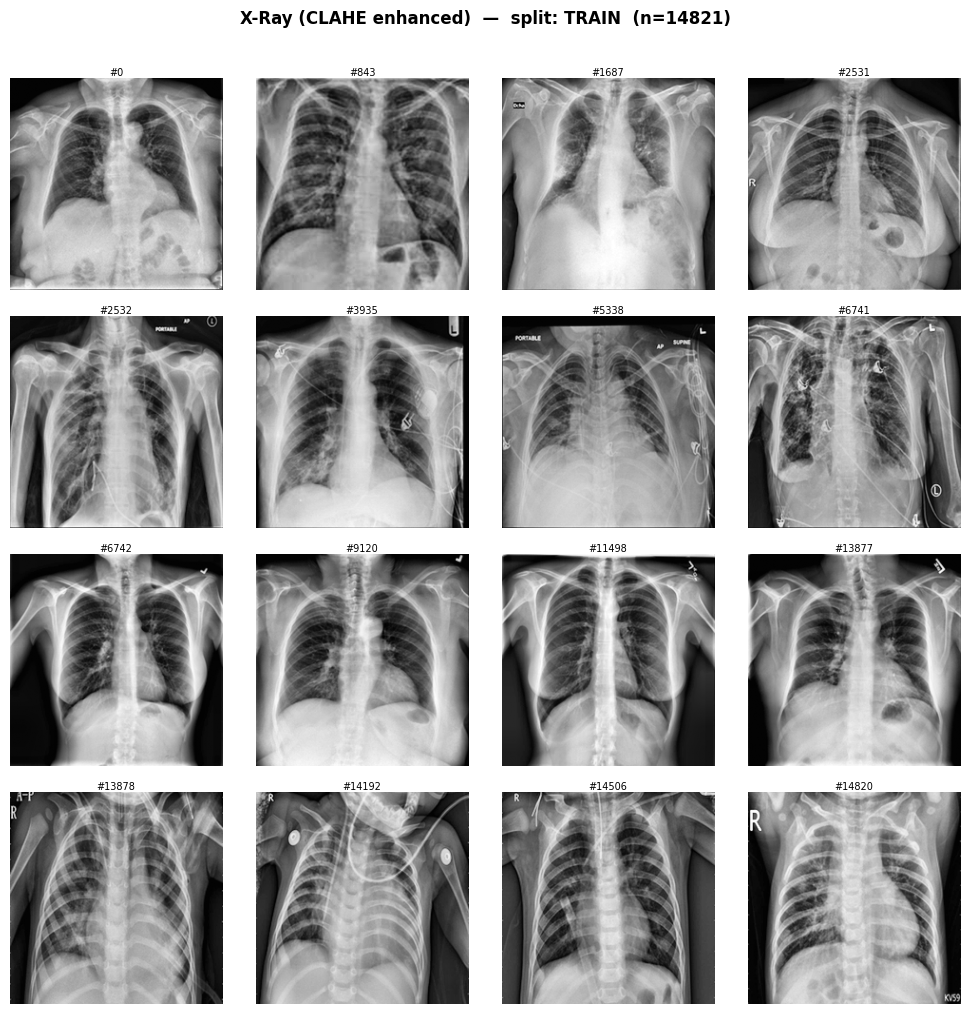

✅ Saved → preprocessed/xray_visual_samples.png


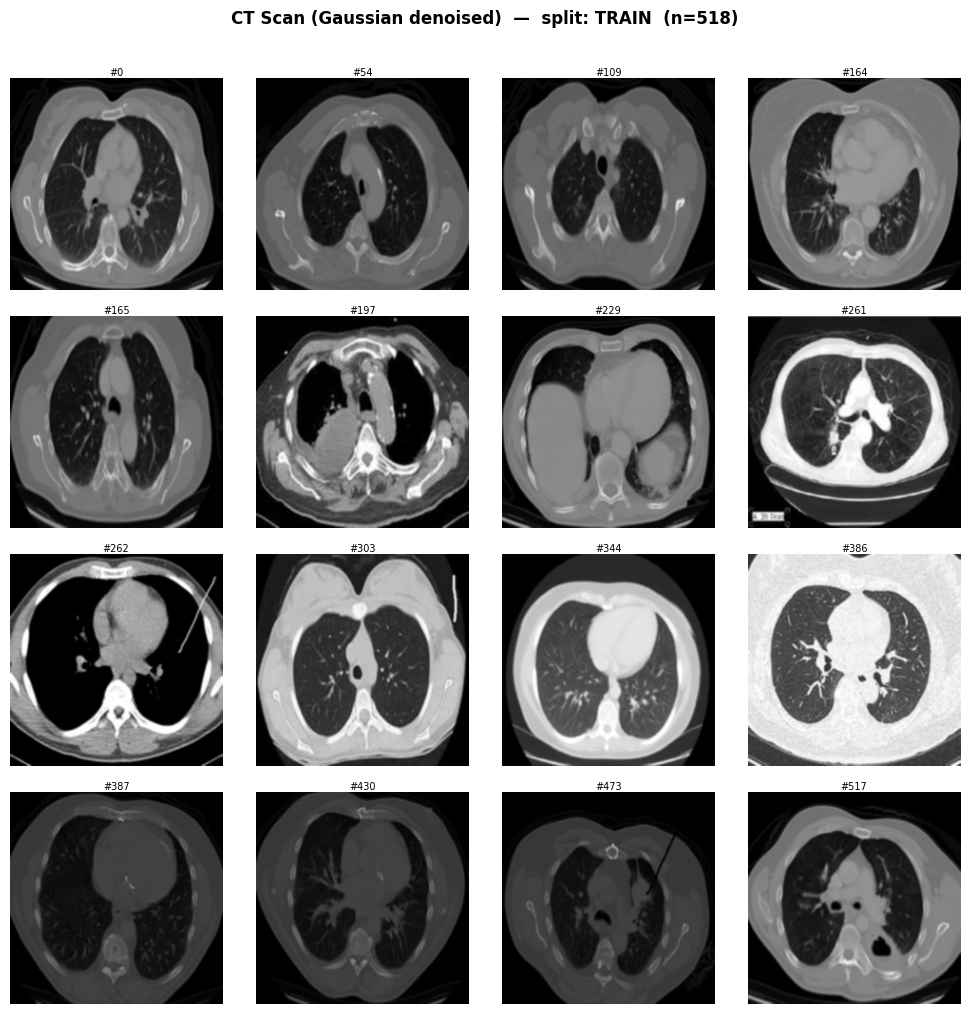

✅ Saved → preprocessed/ct_visual_samples.png


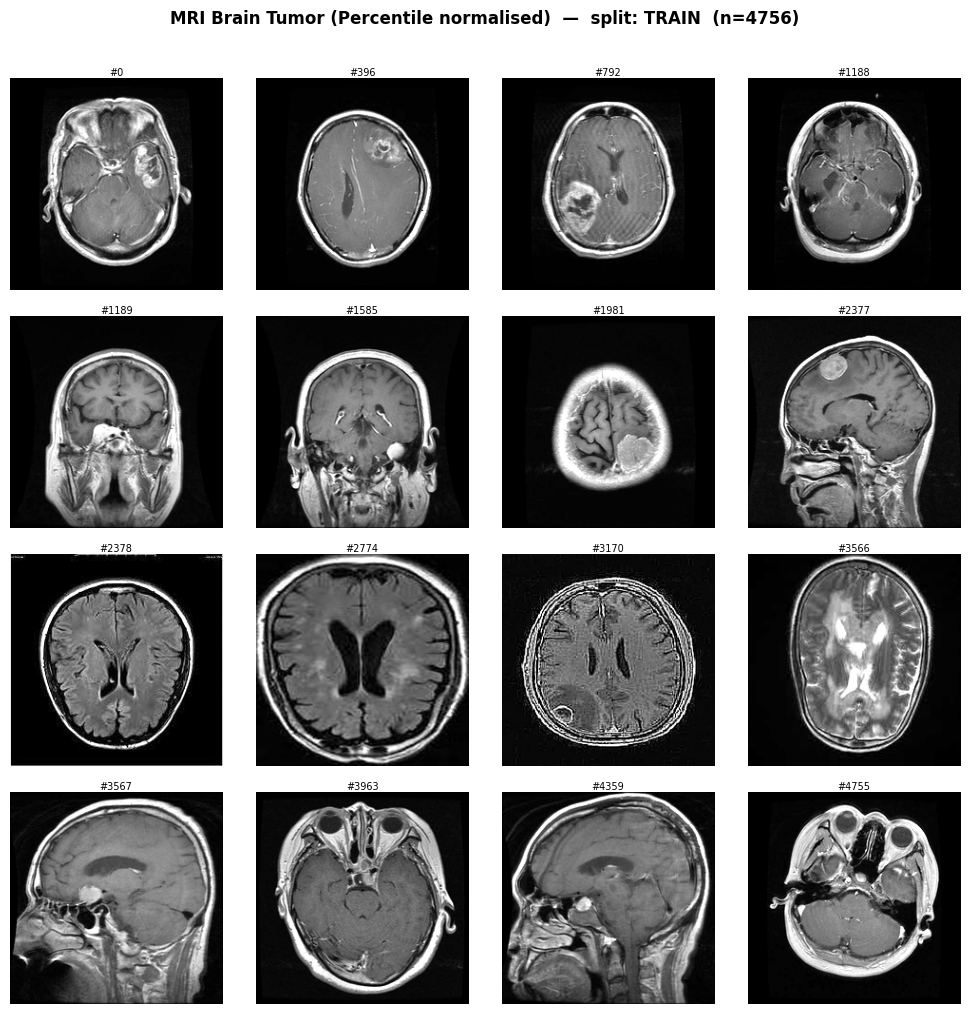

✅ Saved → preprocessed/mri_visual_samples.png

✅ Visual QC complete.
   Review the images above to confirm preprocessing is correct.
   If they look wrong, adjust the preprocessing functions in Cell 2.


In [ ]:
# ── CELL 8 — Visual Quality Check ────────────────────────────────────────────
# Shows preprocessed samples from X_visual.npy (no float-range confusion).
# Use this to manually verify preprocessing is correct before training.

import matplotlib.pyplot as plt

MODALITY_CLASSES = {
    'xray': ['COVID', 'Lung_Opacity', 'Normal', 'Viral Pneumonia'],
    'ct':   ['adenocarcinoma', 'large cell carcinoma', 'normal', 'squamous cell carcinoma'],
    'mri':  ['glioma', 'meningioma', 'notumor', 'pituitary'],
}
MODALITY_CMAPS = {'xray': 'gray', 'ct': None, 'mri': 'gray'}
N_SHOW = 4

for modality in ['xray', 'ct', 'mri']:
    classes = MODALITY_CLASSES[modality]
    n_cls   = len(classes)
    split   = 'train'

    xv_path = OUT_DIR / modality / split / 'X_visual.npy'
    y_path  = OUT_DIR / modality / split / 'y.npy'

    if not (xv_path.exists() and y_path.exists()):
        print(f'⚠️  {modality}/{split} visual file not found — skipping')
        continue

    y = np.load(str(y_path))
    n = len(y)
    X = np.memmap(str(xv_path), dtype='uint8', mode='r',
                  shape=(n, IMG_SIZE, IMG_SIZE, 3))

    fig, axes = plt.subplots(n_cls, N_SHOW, figsize=(N_SHOW * 2.5, n_cls * 2.5))
    if n_cls == 1: axes = axes[np.newaxis, :]
    cmap_name = MODALITY_CMAPS.get(modality)
    title_map = {
        'xray': 'X-Ray (CLAHE enhanced)',
        'ct':   'CT Scan (Gaussian denoised)',
        'mri':  'MRI Brain Tumor (Percentile normalised)'
    }
    fig.suptitle(f'{title_map[modality]}  —  split: TRAIN  (n={n})',
                 fontsize=12, fontweight='bold', y=1.01)

    for row, cls_idx in enumerate(range(n_cls)):
        cls_indices = np.where(y == cls_idx)[0]
        if len(cls_indices) == 0:
            for col in range(N_SHOW):
                axes[row, col].axis('off')
                axes[row, col].set_title('no samples', fontsize=7)
            continue
        pick = np.linspace(0, len(cls_indices) - 1, N_SHOW, dtype=int)
        for col, idx in enumerate(cls_indices[pick]):
            img = np.array(X[idx], copy=True)
            if cmap_name == 'gray':
                axes[row, col].imshow(img[:,:,0], cmap='gray', vmin=0, vmax=255)
            else:
                axes[row, col].imshow(img)
            axes[row, col].axis('off')
            if col == 0:
                axes[row, col].set_ylabel(
                    classes[cls_idx], fontsize=8, rotation=0, labelpad=60, va='center')
            axes[row, col].set_title(f'#{idx}', fontsize=7, pad=2)

    plt.tight_layout()
    save_path = f'preprocessed/{modality}_visual_samples.png'
    plt.savefig(save_path, dpi=120, bbox_inches='tight')
    plt.show()
    del X
    print(f'✅ Saved → {save_path}')

print('\n✅ Visual QC complete.')
print('   Review the images above to confirm preprocessing is correct.')
print('   If they look wrong, adjust the preprocessing functions in Cell 2.')


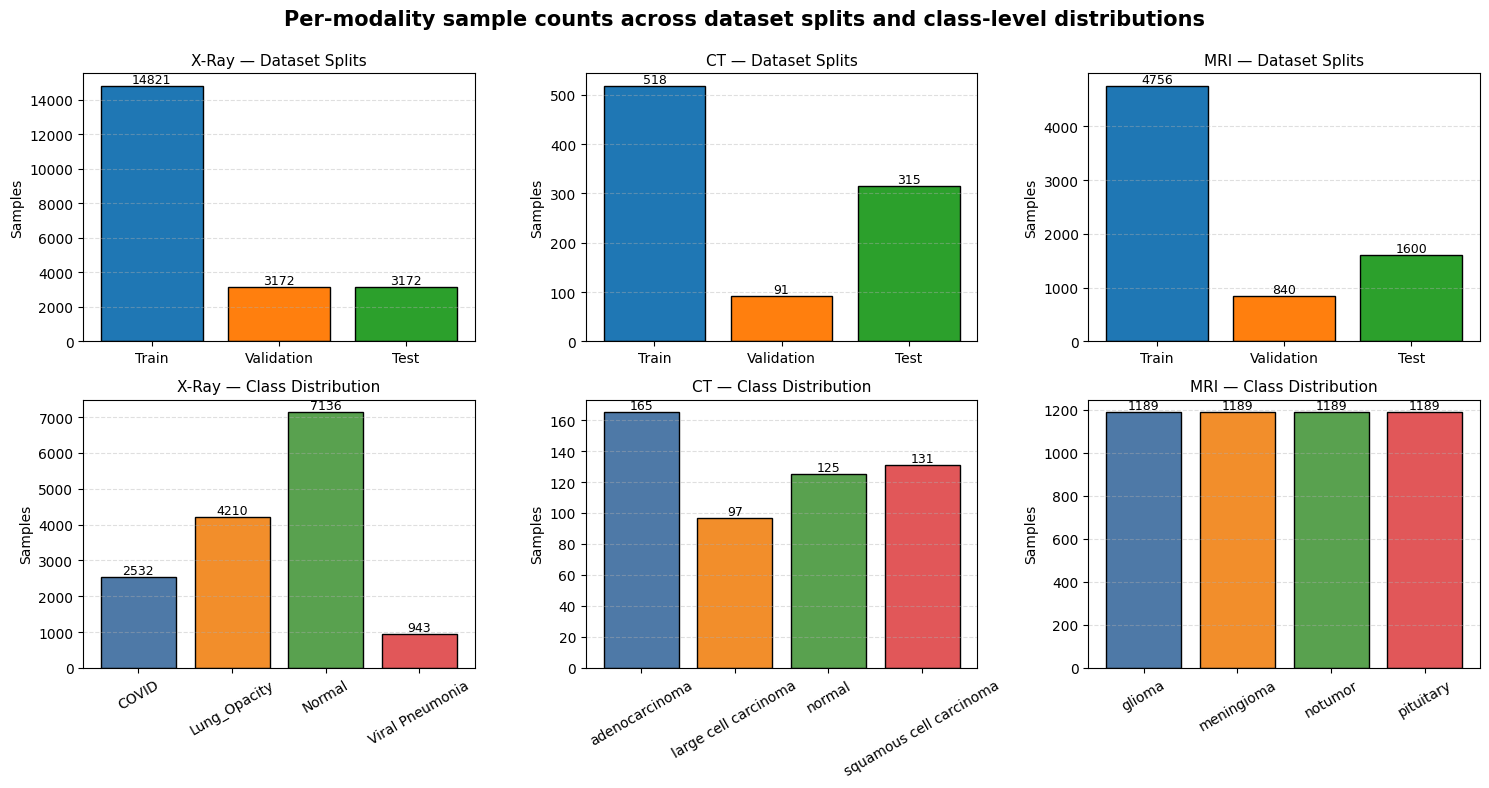

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# -----------------------------
# CLASS NAMES
# -----------------------------

XRAY_CLASSES = ['COVID', 'Lung_Opacity', 'Normal', 'Viral Pneumonia']
CT_CLASSES   = ['adenocarcinoma', 'large cell carcinoma',
                'normal', 'squamous cell carcinoma']
MRI_CLASSES  = ['glioma', 'meningioma', 'notumor', 'pituitary']

# -----------------------------
# DATA
# -----------------------------

splits = ["Train", "Validation", "Test"]

data_counts = {
    "X-Ray": [14821, 3172, 3172],
    "CT": [518, 91, 315],
    "MRI": [4756, 840, 1600]
}

class_dist = {
    "X-Ray": [2532, 4210, 7136, 943],
    "CT": [165, 97, 125, 131],
    "MRI": [1189, 1189, 1189, 1189]
}

class_labels = {
    "X-Ray": XRAY_CLASSES,
    "CT": CT_CLASSES,
    "MRI": MRI_CLASSES
}

modalities = ["X-Ray", "CT", "MRI"]

# -----------------------------
# COLORS
# -----------------------------

split_colors = ['#1f77b4', '#ff7f0e', '#2ca02c']
class_colors = ['#4E79A7', '#F28E2B', '#59A14F', '#E15759']

# -----------------------------
# FIGURE
# -----------------------------

fig, axes = plt.subplots(2, 3, figsize=(15, 8))

# -------- SPLIT DISTRIBUTION --------

for i, modality in enumerate(modalities):
    
    bars = axes[0, i].bar(
        splits,
        data_counts[modality],
        color=split_colors,
        edgecolor='black'
    )
    
    axes[0, i].set_title(f"{modality} — Dataset Splits", fontsize=11)
    axes[0, i].set_ylabel("Samples")
    axes[0, i].grid(axis='y', linestyle='--', alpha=0.4)

    # annotate bars
    for bar in bars:
        height = bar.get_height()
        axes[0, i].text(
            bar.get_x() + bar.get_width()/2,
            height,
            f'{height}',
            ha='center',
            va='bottom',
            fontsize=9
        )

# -------- CLASS DISTRIBUTION --------

for i, modality in enumerate(modalities):
    
    bars = axes[1, i].bar(
        class_labels[modality],
        class_dist[modality],
        color=class_colors,
        edgecolor='black'
    )
    
    axes[1, i].set_title(f"{modality} — Class Distribution", fontsize=11)
    axes[1, i].set_ylabel("Samples")
    axes[1, i].grid(axis='y', linestyle='--', alpha=0.4)
    axes[1, i].tick_params(axis='x', rotation=30)

    for bar in bars:
        height = bar.get_height()
        axes[1, i].text(
            bar.get_x() + bar.get_width()/2,
            height,
            f'{height}',
            ha='center',
            va='bottom',
            fontsize=9
        )

# -----------------------------
# TITLE
# -----------------------------

plt.suptitle(
    "Per-modality sample counts across dataset splits and class-level distributions",
    fontsize=15,
    fontweight='bold'
)

plt.tight_layout()
plt.subplots_adjust(top=0.90)

# Save high resolution
plt.savefig("dataset_statistics.png", dpi=300, bbox_inches='tight')

plt.show()
